### PHASE 1 : PREPROCESSING
* BCI Competition IV Dataset 2a
* Channels: C3, Cz, C4
* All subjects: A01, A02, A03, A04, A05, A06, A07, A08, A09

In [ ]:
import warnings
import mne
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings(
    "ignore",
    message="Could not determine channel type of the following channels, they will be set as EEG:*"
 )

Final EEG shape: (1294, 3, 1001)
Final labels shape: (1294,)


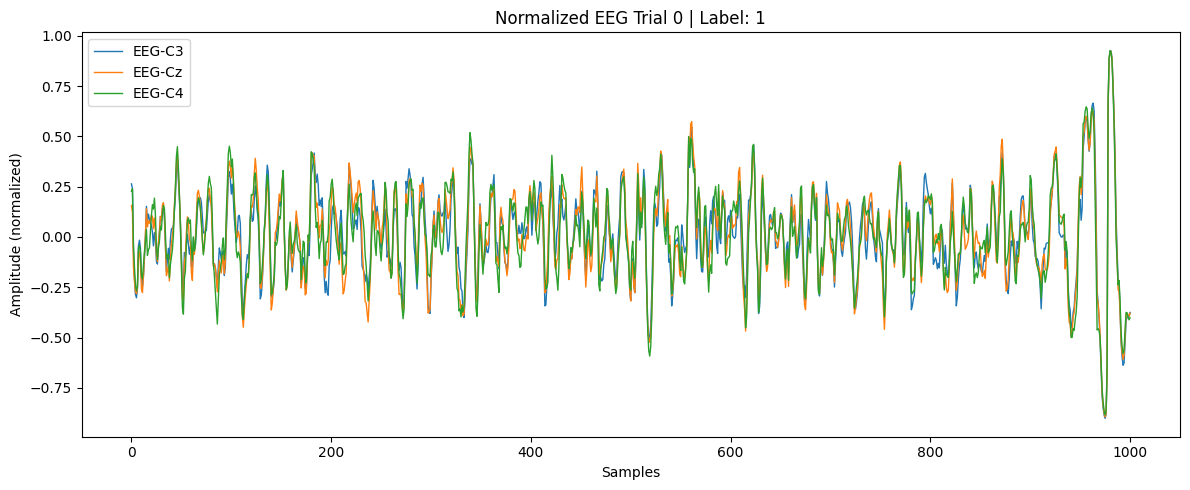

In [ ]:
# Will store data from all subjects in these arrays
all_X = []
all_y = []

# Loop through subjects 1 to 9
for subject in range(1, 10):

    # Creates filenames:
    # A01T.gdf, A02T.gdf, ..., A09T.gdf
    file_path = f"BCICIV_2a_gdf\\A{subject:02d}T.gdf"

    # Load EEG recording (suppress reader warnings)
    raw = mne.io.read_raw_gdf(file_path, preload=True, verbose="ERROR")

    # Explicitly mark known EOG channels when present
    eog_channels = ["EOG-left", "EOG-central", "EOG-right"]
    present_eog = {ch: "eog" for ch in eog_channels if ch in raw.ch_names}
    if present_eog:
        raw.set_channel_types(present_eog)

    # Keep only motor cortex channels
    raw.pick(["EEG-C3", "EEG-Cz", "EEG-C4"])

    # Motor imagery frequency range       (alpha, beta, gamma)
    raw.filter(8, 30, verbose="ERROR")

    # Extract event markers
    events, event_dict = mne.events_from_annotations(raw, verbose="ERROR")

    # Keep only left hand ("769") and right hand ("770") events
    available_events = {
        k: v for k, v in event_dict.items()
        if k in ["769", "770"]
    }

    # Create trials from 2s to 6s after cue
    epochs = mne.Epochs(
        raw,
        events,
        event_id=available_events,
        tmin=2,
        tmax=6,
        baseline=None,
        preload=True,
        verbose="ERROR"
    )

    # EEG data
    X = epochs.get_data()

    # Labels
    y = epochs.events[:, 2]

    # Map MNE internal IDs for '769' (left) and '770' (right) to 0 and 1
    subject_label_map = {}
    if "769" in epochs.event_id:
        subject_label_map[epochs.event_id["769"]] = 0
    if "770" in epochs.event_id:
        subject_label_map[epochs.event_id["770"]] = 1

    y = np.vectorize(subject_label_map.get)(y).astype(np.int64)

    # Store current subject
    all_X.append(X)            # [subject1_array, subject2_array, subject3_array, ...]
    all_y.append(y)

# Combine all subjects   : merges all those subject arrays into one big array:

X = np.concatenate(all_X, axis=0)         # X = [all trials from all subjects combined]
y = np.concatenate(all_y, axis=0)

# Normalize EEG values to [-1, 1]
scaler = MinMaxScaler(feature_range=(-1, 1))
X_flat = X.reshape(-1, X.shape[-1])             # Reshape to 2D for scaler (trials*channels, samples) 
X_norm = scaler.fit_transform(X_flat)
X_norm = X_norm.reshape(X.shape)              # Reshape back to original 3D shape (trials, channels, samples)

# Save dataset
np.save("X_preprocessed2.npy", X_norm)
np.save("y.npy", y)

print("Final EEG shape:", X_norm.shape)
print("Final labels shape:", y.shape)

#  visualization: first trial, all three channels
trial_idx = 0
channel_names = ["EEG-C3", "EEG-Cz", "EEG-C4"]

plt.figure(figsize=(12, 5))
for ch_idx, ch_name in enumerate(channel_names):
    plt.plot(X_norm[trial_idx, ch_idx, :], label=ch_name, linewidth=1.0)

plt.title(f"Normalized EEG Trial {trial_idx} | Label: {y[trial_idx]}")
plt.xlabel("Samples")
plt.ylabel("Amplitude (normalized)")
plt.legend()
plt.tight_layout()
plt.show()


### PHASE 2: BASELINE CNN CLASSIFIER

In [2]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    DepthwiseConv2D,
    SeparableConv2D,
    AveragePooling2D,
    BatchNormalization,
    Activation,
    Dense,
    Dropout,
    Flatten
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.constraints import max_norm

In [4]:
print(np.unique(y, return_counts=True))

(array([0, 1]), array([646, 648]))


In [ ]:
# STEP 1: LOADING DATA

# X_preprocessed2.npy already contains the combined EEG trials from all subjects.
X = np.load("X_preprocessed2.npy")         # our epoch shape : (no of trials, no of channels, no of samples) : (1294, 3, 1001)
y = np.load("y.npy")

# Labels are already compact 0-1 (binary classification: left vs right hand).
print("Loaded combined-subject EEG data (Binary: Left vs Right)")
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Class distribution:", np.unique(y, return_counts=True))

# Per-trial, per-channel z-score normalization works better than a global min-max scale
# for CNNs on EEG because it preserves local trial dynamics.
X = X.astype(np.float32)
X = (X - X.mean(axis=2, keepdims=True)) / (X.std(axis=2, keepdims=True) + 1e-8)
X = np.nan_to_num(X)

# EEGNet-style 2D CNN expects an explicit singleton spatial dimension.
# Shape becomes: (samples , channels , time , 1)
X = X[..., np.newaxis]              # slicing and adding a new empty dimension

print("CNN Input Shape:")   
print(X.shape)

# STEP 2: TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

class_labels = np.unique(y_train)
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=class_labels,
    y=y_train
)
class_weight_dict = dict(zip(class_labels, class_weights))

# STEP 3: BUILD CNN

model = Sequential([
    Input(shape=X_train.shape[1:]),
    Conv2D(16, (1, 64), padding="same", use_bias=False),
    BatchNormalization(),
    DepthwiseConv2D((3, 1), use_bias=False, depth_multiplier=2, depthwise_constraint=max_norm(1.0)),
    BatchNormalization(),
    Activation("elu"),
    AveragePooling2D((1, 4)),
    Dropout(0.25),

    SeparableConv2D(32, (1, 16), padding="same", use_bias=False),
    BatchNormalization(),
    Activation("elu"),
    AveragePooling2D((1, 8)),
    Dropout(0.25),

    Flatten(),
    Dense(2, activation="softmax")
])

# STEP 4: COMPILE

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# STEP 5: TRAIN

callbacks = [
    EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-5)
]

history = model.fit(
    X_train,
    y_train,
    epochs=60,
    batch_size=64,
    validation_split=0.2,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

# STEP 6: TEST

y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average="macro", zero_division=0)
rec = recall_score(y_test, y_pred, average="macro", zero_division=0)
f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)

print("\nRESULTS")
print("Accuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)
print("F1 Score :", f1)
print("\nClassification report:\n")
print(classification_report(y_test, y_pred, digits=4, zero_division=0))


Loaded combined-subject EEG data (Binary: Left vs Right)
X shape: (1294, 3, 1001)
y shape: (1294,)
Class distribution: (array([0, 1]), array([646, 648]))
CNN Input Shape:
(1294, 3, 1001, 1)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 3, 1001, 16)    │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 3, 1001, 16)    │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d                │ (None, 1, 1001, 32)    │            96 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1, 1001, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 1, 1001, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 1, 250, 32)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 250, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d                │ (None, 1, 250, 32)     │         1,536 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1, 250, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 1, 250, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 1, 31, 32)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1, 31, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 992)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │         1,986 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,962 (19.38 KB)

 Trainable params: 4,802 (18.76 KB)

 Non-trainable params: 160 (640.00 B)

Epoch 1/60
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.5097 - loss: 0.7366 - val_accuracy: 0.4831 - val_loss: 0.6932 - learning_rate: 0.0010
Epoch 2/60
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.5012 - loss: 0.7183 - val_accuracy: 0.4734 - val_loss: 0.6928 - learning_rate: 0.0010
Epoch 3/60
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.5628 - loss: 0.6845 - val_accuracy: 0.5266 - val_loss: 0.6921 - learning_rate: 0.0010
Epoch 4/60
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.5592 - loss: 0.6856 - val_accuracy: 0.5266 - val_loss: 0.6918 - learning_rate: 0.0010
Epoch 5/60
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.5809 - loss: 0.6597 - val_accuracy: 0.5314 - val_loss: 0.6917 - learning_rate: 0.0010
Epoch 6/60
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.6075 - loss: 0.6508 - val_accuracy: 0.5266 - val_loss: 0.6912 - learning_rate: 0.0010
Epoch 7/60
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.6232 - loss: 0.6468 - val_acc